In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets

customers = pd.read_csv("Customers.csv")
orders = pd.read_csv("Orders.csv")
books = pd.read_csv("Books.csv")

In [3]:
# Display basic info

print(customers.info())
print(orders.info())
print(books.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  500 non-null    int64 
 1   Name         500 non-null    object
 2   Email        500 non-null    object
 3   Phone        500 non-null    int64 
 4   City         500 non-null    object
 5   Country      500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      500 non-null    int64  
 1   Customer_ID   500 non-null    int64  
 2   Book_ID       500 non-null    int64  
 3   Order_Date    500 non-null    object 
 4   Quantity      500 non-null    int64  
 5   Total_Amount  500 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 23.6+ KB
N

In [4]:
# Display first few rows
print(customers.head())
print(orders.head())
print(books.head())

   Customer_ID              Name                            Email       Phone  \
0            1  Deborah Griffith      balljoseph@wright-keith.net  1234567891   
1            2  Crystal Clements       kimberlybennett@curtis.com  1234567892   
2            3      Susan Fuller  beanmichael@burnett-stewart.net  1234567893   
3            4     Jamie Ramirez            amandahood@warren.com  1234567894   
4            5     Marcus Murphy             connerjohn@yahoo.com  1234567895   

              City            Country  
0  South Craigfort            Denmark  
1   East Derekberg          Nicaragua  
2       Austinbury  Equatorial Guinea  
3       Dianamouth           Slovenia  
4        Smithbury      Guinea-Bissau  
   Order_ID  Customer_ID  Book_ID  Order_Date  Quantity  Total_Amount
0         1           84      169  2023-05-26         8        188.56
1         2          137      301  2023-01-23        10        216.60
2         3          216      261  2024-05-27         6        

In [5]:
#Check for Missing Values

print(customers.isnull().sum())
print(orders.isnull().sum())
print(books.isnull().sum())

Customer_ID    0
Name           0
Email          0
Phone          0
City           0
Country        0
dtype: int64
Order_ID        0
Customer_ID     0
Book_ID         0
Order_Date      0
Quantity        0
Total_Amount    0
dtype: int64
Book_ID           0
Title             0
Author            0
Genre             0
Published_Year    0
Price             0
Stock             0
dtype: int64


In [6]:
#Summary Statistics of Each Dataset

print(customers.describe())
print(orders.describe())
print(books.describe())

       Customer_ID         Phone
count   500.000000  5.000000e+02
mean    250.500000  1.234568e+09
std     144.481833  1.444818e+02
min       1.000000  1.234568e+09
25%     125.750000  1.234568e+09
50%     250.500000  1.234568e+09
75%     375.250000  1.234568e+09
max     500.000000  1.234568e+09
         Order_ID  Customer_ID     Book_ID    Quantity  Total_Amount
count  500.000000   500.000000  500.000000  500.000000    500.000000
mean   250.500000   254.118000  250.452000    5.394000    151.257320
std    144.481833   144.743211  144.401452    2.937349    118.775038
min      1.000000     2.000000    1.000000    1.000000      5.370000
25%    125.750000   131.000000  120.750000    3.000000     49.122500
50%    250.500000   259.000000  245.000000    5.000000    124.390000
75%    375.250000   383.250000  380.250000    8.000000    221.710000
max    500.000000   500.000000  497.000000   10.000000    491.500000
          Book_ID  Published_Year       Price       Stock
count  500.000000      5

In [22]:
# Merge Orders with Customers and Books for analysis

df = orders.merge(customers, on='Customer_ID').merge(books, on='Book_ID')

In [93]:
# Customer Analysis:
# Customers Who Made the Most Orders

top_ordering_customers = orders["Customer_ID"].value_counts().head(10)
print(top_ordering_customers)

Customer_ID
364    6
474    5
325    4
107    4
405    4
457    4
437    4
485    4
174    4
425    4
Name: count, dtype: int64


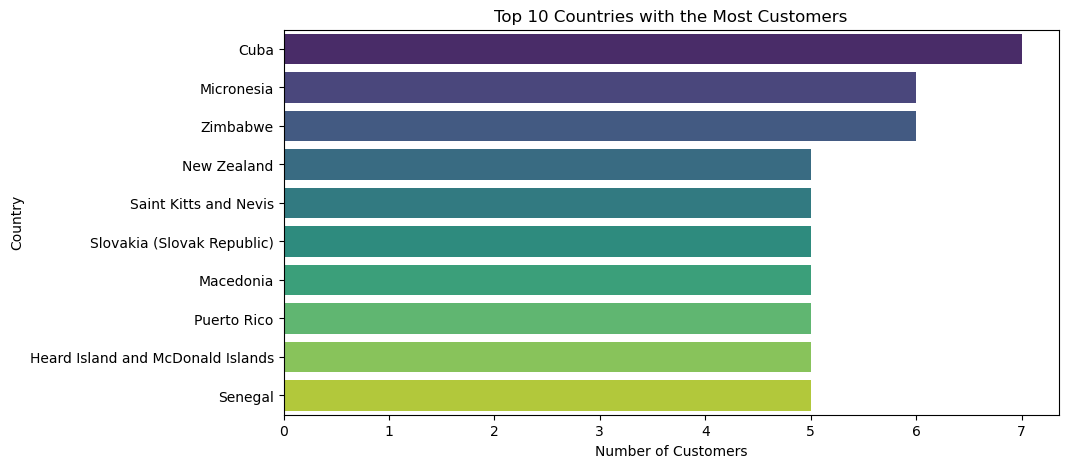

In [81]:
# Customer Analysis:
# What are the top 10 countries with the most customers?

top_countries = customers["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="viridis", legend=False)

plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.title("Top 10 Countries with the Most Customers")
plt.show()



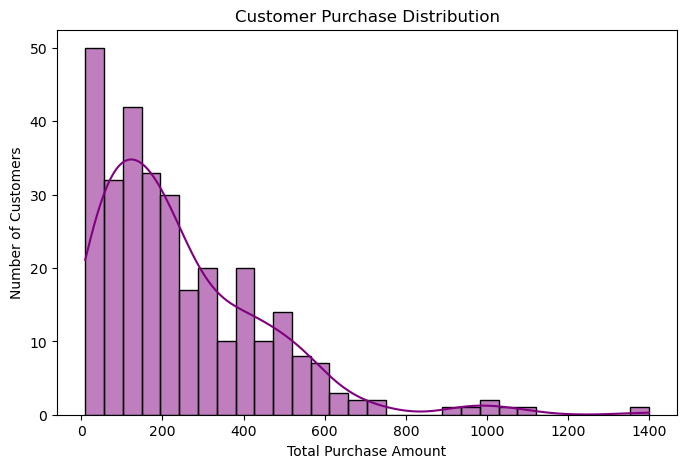

In [28]:
# Customer Analysis:
# Customer Purchase Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df.groupby('Customer_ID')['Total_Amount'].sum(), bins=30, kde=True, color='purple')
plt.xlabel("Total Purchase Amount")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Distribution")
plt.show()

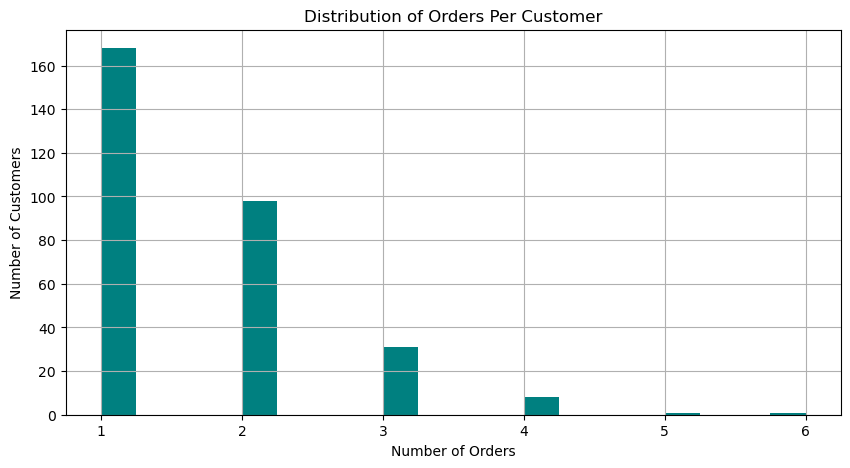

In [30]:
# Customer Analysis:
# Number of Orders Per Customer

customer_orders = df['Customer_ID'].value_counts()
plt.figure(figsize=(10, 5))
customer_orders.hist(bins=20, color='teal')
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Distribution of Orders Per Customer")
plt.show()

In [24]:
# Book Sales Performance:
#Find the Top-Selling Books by Quantity

top_books = orders.groupby("Book_ID")["Quantity"].sum().sort_values(ascending=False).head(10)
print(top_books)


Book_ID
73     28
31     27
157    24
273    24
288    23
120    23
307    23
208    23
142    22
196    22
Name: Quantity, dtype: int64


In [79]:
# Book Sales Performance:
# Find the Most Profitable Books (Revenue)

top_revenue_books = orders.groupby("Book_ID")["Total_Amount"].sum().sort_values(ascending=False).head(10)
print(top_revenue_books)

Book_ID
120    1104.69
142    1077.12
119    1047.48
471     952.98
422     872.29
147     813.60
298     793.22
88      764.18
49      742.50
240     698.60
Name: Total_Amount, dtype: float64


In [103]:
# Book Sales Performance:
# Find book details by Book_ID

book_id = 120
book_info = books[books["Book_ID"] == book_id]
print("Book Details:")
print(book_info)

Book Details:
     Book_ID                        Title         Author        Genre  \
119      120  Integrated secondary access  Sheena Harris  Non-Fiction   

     Published_Year  Price  Stock  
119            1984  48.03     93  


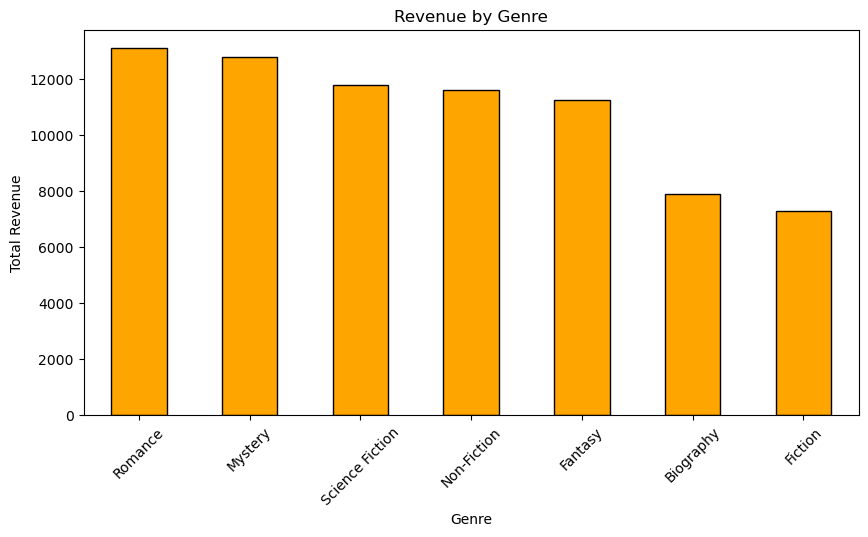

In [26]:
# Book Sales Performance:
# Revenue by Genre

genre_revenue = df.groupby('Genre')['Total_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
genre_revenue.plot(kind='bar', color='orange',edgecolor='black')
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.title("Revenue by Genre")
plt.xticks(rotation=45)
plt.show()


In [67]:
# Book Sales Performance:
# Highest Priced Books

most_expensive_books = books.sort_values(by="Price", ascending=False).head(10)
print(most_expensive_books)


     Book_ID                                    Title            Author  \
339      340    Proactive system-worthy orchestration      Robert Scott   
154      155  Optimized content-based standardization     Timothy Adams   
239      240            Stand-alone content-based hub        Lisa Ellis   
99       100  Synchronized client-server service-desk    James Alvarado   
118      119            Switchable modular moratorium    Tonya Saunders   
259      260  Business-focused methodical application        Brian King   
94        95        Function-based heuristic analyzer       Craig Smith   
48        49        Robust attitude-oriented attitude     Zachary Hayes   
140      141              Exclusive hybrid monitoring  Dr. Heather Boyd   
359      360               Profound tertiary encoding    Jennifer Jones   

               Genre  Published_Year  Price  Stock  
339          Mystery            1907  49.98     88  
154  Science Fiction            1901  49.96     88  
239          Fa

In [49]:
# Book Sales Performance:
# Books That Are Out of Stock

out_of_stock_books = books[books["Stock"] == 0]
print(out_of_stock_books)

     Book_ID                                 Title            Author  \
43        44     Networked systemic implementation        Ryan Frank   
59        60           Robust eco-centric capacity       Brian Haney   
126      127  Business-focused real-time benchmark      David Nelson   
162      163    Object-based eco-centric challenge  Douglas Mccarthy   
377      378     Future-proofed heuristic function  Samantha Mcclain   

               Genre  Published_Year  Price  Stock  
43   Science Fiction            1965  13.55      0  
59         Biography            1990  35.14      0  
126  Science Fiction            1997  11.66      0  
162      Non-Fiction            1905  19.11      0  
377          Romance            1903   6.01      0  


In [63]:
# Book Sales Performance:
#  Top 5 High-Stock Books

high_stock_books = books.sort_values(by='Stock', ascending=False).head(5)
print("Top 5 Books with Highest Stock:")
print(high_stock_books[['Title', 'Stock']])


Top 5 Books with Highest Stock:
                                         Title  Stock
0              Configurable modular throughput    100
368             Diverse responsive focus group    100
172     Ergonomic foreground Graphic Interface    100
192      Customer-focused tertiary methodology    100
253  Team-oriented bandwidth-monitored project    100


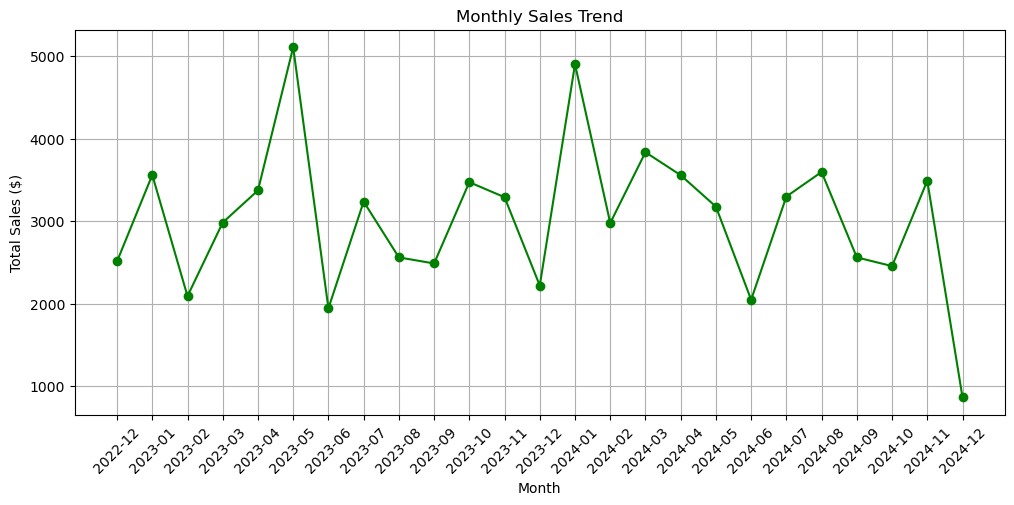

In [85]:
# Sales Trends & Seasonality:
# Yearly Sales Trends (Visualization)

orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])
orders["Month"] = orders["Order_Date"].dt.strftime("%Y-%m")

monthly_sales = orders.groupby("Month")["Total_Amount"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", linestyle="-", color="g")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()


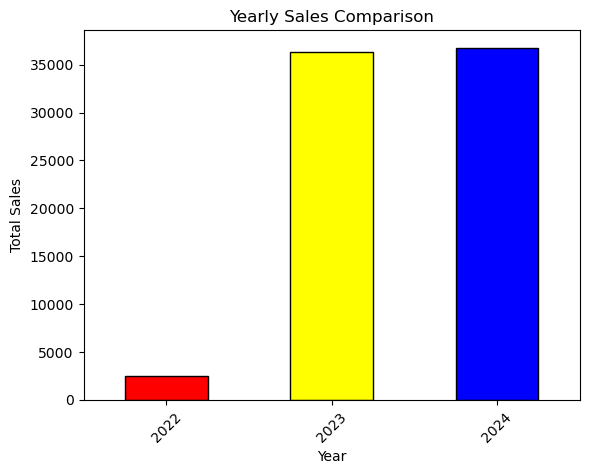

In [95]:
# Sales Trends & Seasonality:
#  Yearly Sales Comparison

yearly_sales = df.groupby(df['Order_Date'].dt.year)['Total_Amount'].sum()
yearly_sales.plot(kind='bar', color=['Red',"Yellow","Blue"],edgecolor="Black")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Comparison")
plt.xticks(rotation=45)
plt.show()

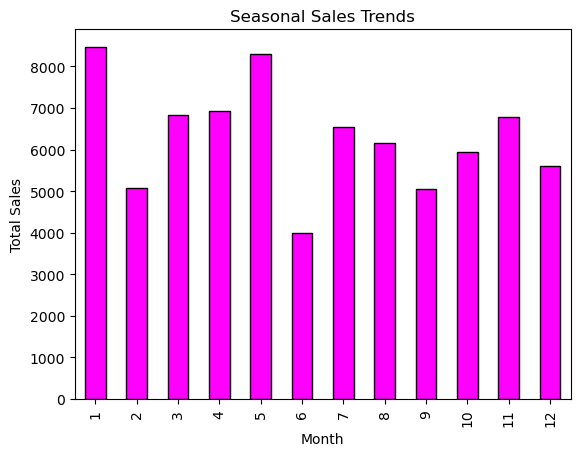

In [51]:
# Sales Trends & Seasonality:
# Seasonal Sales Trends

df['Month'] = df['Order_Date'].dt.month
seasonal_sales = df.groupby('Month')['Total_Amount'].sum()
seasonal_sales.plot(kind='bar', color='magenta',edgecolor="black")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Seasonal Sales Trends")
plt.show()

In [34]:
# Average Order Value (AOV)

aov = np.mean(orders["Total_Amount"])
print(f"Average Order Value: ${aov:.2f}")

Average Order Value: $151.26


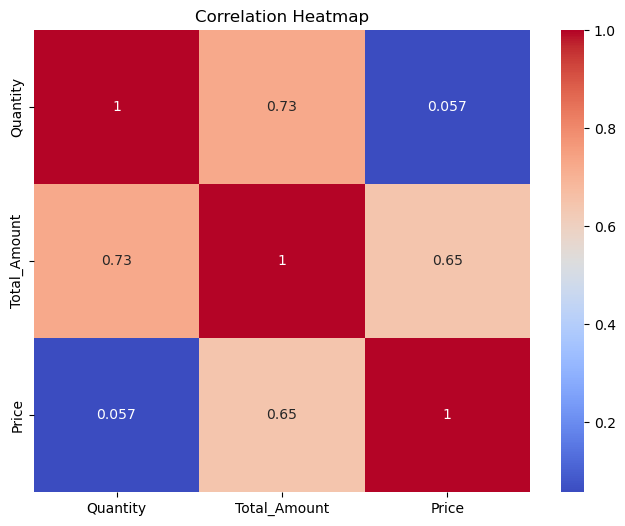

In [65]:
#  Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Quantity', 'Total_Amount', 'Price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [109]:
# Conclusion & Key Insights
print("1) The majority of customers come from Cuba country.")
print("2) The best-selling book is Integrated secondary access by Harris, generating 1104.69 revenue.")
print("3) Sales peak during Q4, indicating strong holiday trends.")
print("4) The average order value is $151.26, showing customer spending behavior.")
print("5) Stock levels need better management to avoid lost sales due to stockouts.")

1) The majority of customers come from Cuba country.
2) The best-selling book is Integrated secondary access by Harris, generating 1104.69 revenue.
3) Sales peak during Q4, indicating strong holiday trends.
4) The average order value is $151.26, showing customer spending behavior.
5) Stock levels need better management to avoid lost sales due to stockouts.
